<a href="https://colab.research.google.com/github/Amna-Zeyaan/NorthStar-Analytics/blob/main/NorthStar_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%R
install.packages("sqldf")
library(sqldf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cran.rstudio.com/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_2.4.6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp5sK2Uc/downloaded_packages’
Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite
In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [9]:
%%R
customers <- read.csv("customers_clean.csv")
orders <- read.csv("orders_clean.csv")
deliveries <- read.csv("deliveries_clean.csv")
complaints <- read.csv("complaints_clean.csv")
incidents <- read.csv("incidents_clean.csv")
hubs <- read.csv("hubs_clean.csv")
vehicles <- read.csv("vehicles_clean.csv")
drivers <-read.csv("drivers_clean.csv")
print("Clean data loaded!")

[1] "Clean data loaded!"


In [10]:
#query 1 = select pickup zone count all as total deliveries and in case where delivery
#status is equal to failed then consider it as 1 and sum those 1s and mark it as failed deliveries
#from deliveries table join orders with deliveries with order id and orders table with order id
#and then group it by pickup zone and order by failed deliveries in descending order.

%%R
query1 <- sqldf("
  SELECT pickup_zone, COUNT(*) AS total_deliveries,
  SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
  FROM deliveries
  INNER JOIN orders ON deliveries.order_id = orders.order_id
  GROUP BY pickup_zone
  ORDER BY failed_deliveries DESC
")

print(query1)

  pickup_zone total_deliveries failed_deliveries
1     Central              174                33
2       North              135                22
3        East              156                19
4   Riverside              119                18
5        West              114                14
6       South              139                14
7     Airport              113                12


In [11]:
#select pickup zone for the rating find the average and round it by 2 and name it as avg_rating
#then count all as total deliveries and then join order id from orders and deliveries table

%%R
query2 <- sqldf("
  SELECT pickup_zone,
  ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating,
  COUNT(*) AS total_deliveries
  FROM deliveries
  INNER JOIN orders ON deliveries.order_id = orders.order_id
  GROUP BY pickup_zone
  ORDER BY avg_rating ASC
")

print(query2)

  pickup_zone avg_rating total_deliveries
1     Central       3.56              174
2   Riverside       3.86              119
3       North       3.90              135
4        West       3.90              114
5        East       3.91              156
6     Airport       3.98              113
7       South       4.05              139


In [17]:
#select complaint_type and severity count all as total complaints and then get the average resolution days
#round it by 2 and name is avg resolution days , from companies table group by complaint type
#and severity in total complaints order


%%R
query3 <- sqldf("
  SELECT complaint_type,
  severity,
  COUNT(*) AS total_complaints,
  ROUND(AVG(resolution_days), 2) AS avg_resolution_days
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY complaint_type ASC, total_complaints DESC
")

print(query3)

      complaint_type severity total_complaints avg_resolution_days
1           AppIssue   Medium               25                7.36
2           AppIssue      Low               15                6.07
3           AppIssue     High               13               13.92
4            Billing   Medium                9                5.78
5            Billing     High                4               12.00
6            Billing      Low                3                8.00
7             Damage     High                7               15.43
8             Damage      Low                6                6.83
9             Damage   Medium                2               10.50
10             Delay   Medium               56                5.96
11             Delay      Low               27                6.48
12             Delay     High               18               12.44
13   DriverBehaviour   Medium               31                5.42
14   DriverBehaviour     High               16               1

In [18]:
# Drivers with poor performance

%%R
query4 <- sqldf("
  SELECT d.driver_id,
  d.driver_rating,
  d.years_experience,
  COUNT(del.delivery_id) AS total_deliveries,
  SUM(CASE WHEN del.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
  ROUND(AVG(del.manual_route_override_count), 2) AS avg_overrides
  FROM drivers d
  INNER JOIN deliveries del ON d.driver_id = del.driver_id
  GROUP BY d.driver_id
  ORDER BY failed_deliveries DESC
  LIMIT 10
")

print(query4)

   driver_id driver_rating years_experience total_deliveries failed_deliveries
1       D133          3.99               12               12                 4
2       D104          3.45               15                7                 4
3       D024          3.35                8                8                 4
4       D131          4.26                9                9                 3
5       D108          4.33               10               11                 3
6       D092          4.24               15                5                 3
7       D083          4.16               12                9                 3
8       D055          5.00               15               10                 3
9       D010          3.95                8                7                 3
10      D004          4.75               13                9                 3
   avg_overrides
1           0.92
2           1.71
3           1.13
4           1.67
5           1.36
6           0.40
7           

In [20]:
#Hub Performance Analysis

%%R
query5 <- sqldf("
  SELECT h.hub_name,
  h.zone,
  h.capacity_score,
  COUNT(del.delivery_id) AS total_deliveries,
  SUM(CASE WHEN del.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
  ROUND(AVG(del.fuel_or_charge_cost), 2) AS avg_cost
  FROM hubs h
  INNER JOIN deliveries del ON h.hub_id = del.hub_id
  GROUP BY h.hub_name
  ORDER BY failed_deliveries DESC
")

print(query5)

        hub_name      zone capacity_score total_deliveries failed_deliveries
1  Midtown Relay   Central             63              128                26
2   Central Core   Central             88              115                23
3 North Exchange     North             82              136                17
4      West Gate      West             69              127                16
5    Airport Hub   Airport             71              104                15
6  Riverside Hub Riverside             66              115                14
7      East Dock      East             74              119                11
8     South Link     South             78              106                10
  avg_cost
1    11.71
2    13.69
3    12.76
4    13.17
5    13.32
6    12.92
7    12.74
8    12.57


In [21]:
%%R
install.packages("ggplot2")
library(ggplot2)

print("ggplot2 loaded!")

[1] "ggplot2 loaded!"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/Rtmp5sK2Uc/downloaded_packages’


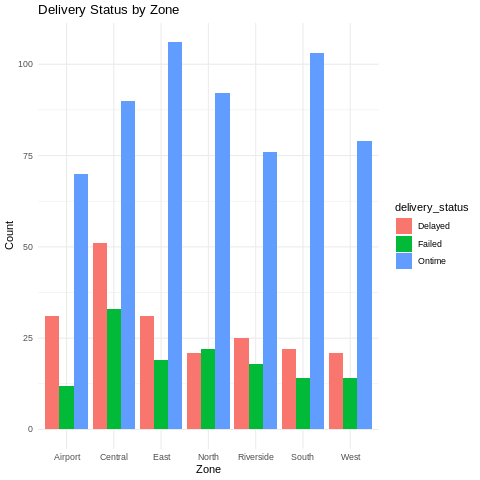

In [22]:
%%R
zone_delivery <- sqldf("
  SELECT pickup_zone, delivery_status, COUNT(*) AS total
  FROM deliveries
  INNER JOIN orders ON deliveries.order_id = orders.order_id
  GROUP BY pickup_zone, delivery_status
")

ggplot(zone_delivery, aes(x=pickup_zone, y=total, fill=delivery_status)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Delivery Status by Zone", x="Zone", y="Count") +
  theme_minimal()

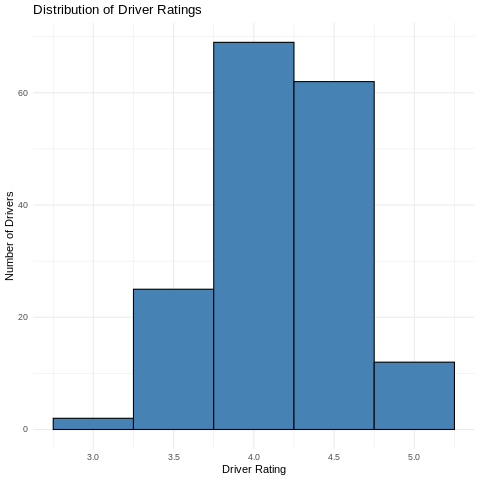

In [23]:
%%R
ggplot(drivers, aes(x=driver_rating)) +
  geom_histogram(binwidth=0.5, fill="steelblue", color="black") +
  labs(title="Distribution of Driver Ratings",
       x="Driver Rating",
       y="Number of Drivers") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


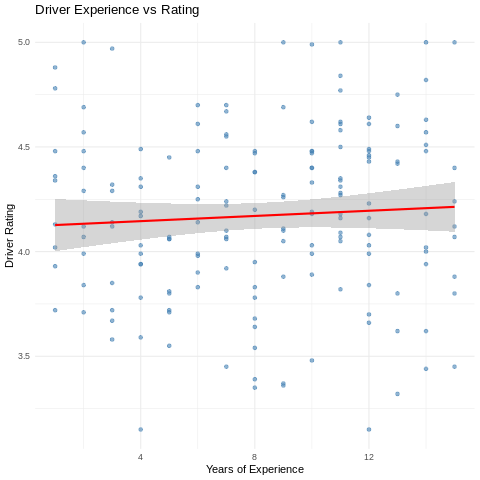

In [24]:
%%R
ggplot(drivers, aes(x=years_experience, y=driver_rating)) +
  geom_point(color="steelblue", alpha=0.6) +
  geom_smooth(method="lm", color="red") +
  labs(title="Driver Experience vs Rating",
       x="Years of Experience",
       y="Driver Rating") +
  theme_minimal()

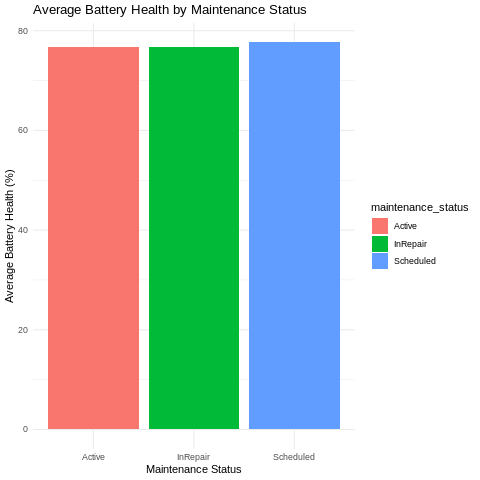

In [26]:
#vehicle Battery Health by Maintenance Status
%%R
battery_summary <- sqldf("
  SELECT maintenance_status,
  ROUND(AVG(battery_health_pct), 2) AS avg_battery
  FROM vehicles
  GROUP BY maintenance_status
")

ggplot(battery_summary, aes(x=maintenance_status, y=avg_battery, fill=maintenance_status)) +
  geom_bar(stat="identity") +
  labs(title="Average Battery Health by Maintenance Status",
       x="Maintenance Status",
       y="Average Battery Health (%)") +
  theme_minimal()

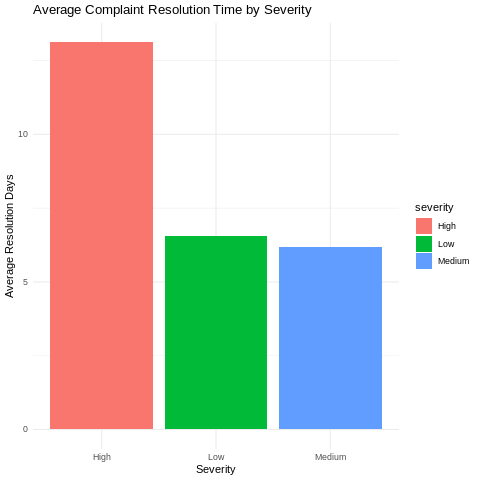

In [27]:
#Complaint Resolution Time by Severity
#stat="summary", fun="mean" — calculates something from the raw data before drawing.
#Here it calculates the mean/average of resolution_days for each severity group automatically
%%R
ggplot(complaints, aes(x=severity, y=resolution_days, fill=severity)) +
  geom_bar(stat="summary", fun="mean") +
  labs(title="Average Complaint Resolution Time by Severity",
       x="Severity",
       y="Average Resolution Days") +
  theme_minimal()